# Volleyball Motion Tracking

## Rhys Pulling

DSCI 503 Project:

Extract data from a video of a volleyball game/play. The dataset is from the following github: https://github.com/shukkkur/VolleyVision/tree/main?tab=readme-ov-file. Then use the data to predict an outcome of the game (score pass, ace, who gets set, etc.).

## Data Collection and Preprocessing

The first step of the project is, of course, finding data and performing any preprocessing that is required. Due to the nature of my project, there will be two parts to preprocessing:
1. Collection and preprocessing of related videos/images
2. Preprocessing of data collected from feature extraction of the videos

I am currently working on part one.

### Collection and Preprocessing of Videos

As mentioned earlier, the data I plan on using I found through the VolleyVision github repository by Shukkur. They have listed various datasets used for different steps in their training filled with thousands of images, so it seems best to utilize these datasets.

The first dataset I downloaded was: [Volleyball_v2 Dataset](https://universe.roboflow.com/shukur-sabzaliev1/volleyball_v2/dataset/2). The format used was yolov8. It is a huge dataset so I stored the file on google drive and will mount my google drive so it doesn't have to be downloaded every time.

In [ ]:
from google.colab import drive
from PIL import Image

# Mount Google Drive for fast, responsible access to files
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import os

# find path and then change directory
# volleypath = '/content/gdrive/MyDrive/College/Mines/DSCI 503/'
# os.chdir(volleypath)

In [ ]:
# unzip the zip file
# runs for awhile, so only run at start of a session
!unzip "/content/gdrive/MyDrive/College/Mines/DSCI 503/Volleyball_v2.v2-640x640.yolov8.zip" -d "/content/Volleyball_v2.v2-640x640.yolov8" # unlabeled images
!unzip "/content/gdrive/MyDrive/College/Mines/DSCI 503/Volleyball Actions.v5-original.yolov8.zip" -d "/content/Volleyball Actions.v5-original.yolov8" # labeled action images

Streaming output truncated to the last 5000 lines.
 extracting: /content/Volleyball Actions.v5-original.yolov8/train/labels/-E3-82-B9-E3-82-AF-E3-83-AA-E3-83-BC-E3-83-B3-E3-82-B7-E3-83-A7-E3-83-83-E3-83-88-202022-10-12-2016-45-22_jpg.rf.7ee5dfc9660d22ac43d3f9356fae93b9.txt  
 extracting: /content/Volleyball Actions.v5-original.yolov8/train/labels/-E3-82-B9-E3-82-AF-E3-83-AA-E3-83-BC-E3-83-B3-E3-82-B7-E3-83-A7-E3-83-83-E3-83-88-202022-10-12-2016-45-22_jpg.rf.e353f5d128a2c50ee46d702e85790526.txt  
 extracting: /content/Volleyball Actions.v5-original.yolov8/train/labels/-E3-82-B9-E3-82-AF-E3-83-AA-E3-83-BC-E3-83-B3-E3-82-B7-E3-83-A7-E3-83-83-E3-83-88-202022-10-12-2016-45-47_jpg.rf.be577bfc46295143be0badceb071ed6a.txt  
 extracting: /content/Volleyball Actions.v5-original.yolov8/train/labels/-E3-82-B9-E3-82-AF-E3-83-AA-E3-83-BC-E3-83-B3-E3-82-B7-E3-83-A7-E3-83-83-E3-83-88-202022-10-12-2016-45-47_jpg.rf.c6a82017d7cd516c36ef82ed1379c36b.txt  
 extracting: /content/Volleyball Actions.v5-origi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

It is already stored with a train, val, and test split so this step of preprocessing does not need to be done here.

In [ ]:
from glob import glob

# unlabeled images
ball_train_images = glob('/content/Volleyball_v2.v2-640x640.yolov8/train/images/*.jpg')
ball_val_images = glob('/content/Volleyball_v2.v2-640x640.yolov8/valid/images/*.jpg')
ball_test_images = glob('/content/Volleyball_v2.v2-640x640.yolov8/test/images/*.jpg')
ball_train_labels = glob('/content/Volleyball_v2.v2-640x640.yolov8/train/labels/*.txt')
ball_val_labels = glob('/content/Volleyball_v2.v2-640x640.yolov8/valid/labels/*.txt')
ball_test_labels = glob('/content/Volleyball_v2.v2-640x640.yolov8/test/labels/*.txt')

# labeled action images
train_images = glob('/content/Volleyball Actions.v5-original.yolov8/train/images/*.jpg')
val_images = glob('/content/Volleyball Actions.v5-original.yolov8/valid/images/*.jpg')
test_images = glob('/content/Volleyball Actions.v5-original.yolov8/test/images/*.jpg')
train_labels = glob('/content/Volleyball Actions.v5-original.yolov8/train/labels/*.txt')
val_labels = glob('/content/Volleyball Actions.v5-original.yolov8/valid/labels/*.txt')
test_labels = glob('/content/Volleyball Actions.v5-original.yolov8/test/labels/*.txt')

len(train_images), len(val_images), len(test_images), len(train_labels), len(val_labels), len(test_labels)

(11019, 1452, 1452, 11019, 1452, 1452)

In [ ]:
# filter out only hitting images
hitting_images = []
hitting_labels = []
for i, label_file in enumerate(train_labels):
    if label_file.endswith('.txt'):
        # Path to the label file
        # label_path = os.path.join(labels_dir, label_file)
        label_path = label_file

        # Read the label file and extract class IDs
        with open(label_path, 'r') as file:
            class_ids = [int(line.split()[0]) for line in file.readlines()]
            if 4 in class_ids:
                hitting_images.append(train_images[i])
                hitting_labels.append(train_labels[i])

len(hitting_images), len(hitting_labels)

(4151, 4151)

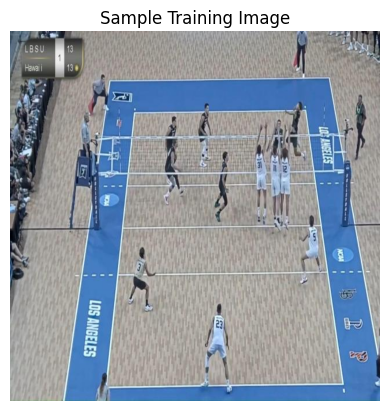

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Display a sample training image
sample_image_path = ball_train_images[2]
image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title('Sample Training Image')
plt.axis('off')
plt.show()

There are different kinds of preprocessing we can do for computer vision, and just for image data in general:
* Resize Images
* Normalization
* Data Augmentation
* Label Encoding
* Examing / Handling Imbalance

In [ ]:
import shutil

# Function to resize and normalize images
# store in new directory
def process_images(image_paths, labels_path, output_images, output_labels, image_size=(640, 640)):
    # Ensure output directory exists
    os.makedirs(output_images, exist_ok=True)
    os.makedirs(output_labels, exist_ok=True)

    cleaned_image_paths = []
    cleaned_label_paths = []

    for i, image_path in enumerate(image_paths):
        image = cv2.imread(image_path)

        # Check if the image was loaded successfully
        if image is not None:
            try:
                # Resize the image
                resized_image = cv2.resize(image, image_size)

                # Normalize the image
                normalized_image = resized_image.astype("float32") / 255.0

                # Define the output path for the cleaned image
                output_image_path = os.path.join(output_images, f"cleaned_image_{i}.jpg")

                # Save the cleaned image
                cv2.imwrite(output_image_path, (normalized_image * 255).astype(np.uint8))

                # Append the path to the list of cleaned image paths
                cleaned_image_paths.append(output_image_path)

                # Get the corresponding label file path
                label_file = labels_path[i]

                if os.path.exists(label_file):
                    # Define the output label path
                    output_label_path = os.path.join(output_labels, f"cleaned_image_{i}.txt")

                    # Copy the label file to the output directory
                    shutil.copy(label_file, output_label_path)

                    # Append the path to the list of cleaned label paths
                    cleaned_label_paths.append(output_label_path)
                else:
                    print(f"No label file found for image: {image_path}")
            except Exception as e:
                print(f"Error processing image {image_path}: {e}")
        else:
            print(f"Error loading image: {image_path}")

    return cleaned_image_paths, cleaned_label_paths

# process images for training on ball
# ball_train_images = process_images(ball_train_images[:1000], ball_train_labels[:1000], './content/cleaned_images/ball/train/images', './content/cleaned_images/ball/train/labels', (320, 320))
# ball_val_images = process_images(ball_val_images[:334], ball_val_labels[:334], './content/cleaned_images/ball/val/images', './content/cleaned_images/ball/val/labels', (320, 320))
# ball_test_images = process_images(ball_test_images[:334], ball_test_labels[:334], './content/cleaned_images/ball/test/images', './content/cleaned_images/ball/test/labels', (320, 320))

# Process the train, validation, and test images, and save them
# cleaned_train_images, cleaned_train_labels  = process_images(train_images[:5000], train_labels[:5000], './content/cleaned_images/train/images', './content/cleaned_images/train/labels', (640, 640))
cleaned_hitting_images, cleaned_hitting_labels  = process_images(hitting_images, hitting_labels, './content/cleaned_images/hitting/images', './content/cleaned_images/hitting/labels', (640, 640)) # try with only images classified as hit
# cleaned_val_images, cleaned_val_labels  = process_images(val_images, val_labels, './content/cleaned_images/val/images', './content/cleaned_images/val/labels', (640, 640))
# cleaned_test_images, cleaned_test_labels  = process_images(test_images, test_labels, './content/cleaned_images/test/images', './content/cleaned_images/test/labels', (640, 640))
# np.array(cleaned_train_images).shape, np.array(cleaned_val_images).shape, np.array(cleaned_test_images).shape

In [ ]:
# Display the preprocessed sample image
# image = cv2.imread(cleaned_train_images[5])
# image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# plt.imshow(image_rgb)
# plt.title('Cleaned Training Image')
# plt.axis('off')
# plt.show()

### Exploratory Data Analysis

Some ways to do EDA on unlabeled image data are:
- Color channel analysis
- Pixel intensity distribution
- Image sampling

In [ ]:
# image sampling
# just looking at a random sample of images
# random_indices = np.random.choice(len(ball_train_images), size=4, replace=False)
# sampled_images = [train_images[i] for i in random_indices]

# fig, axes = plt.subplots(1, 4, figsize=(15, 3))
# for i, ax in enumerate(axes):
#     # Load the image data using cv2.imread
#     image = cv2.imread(sampled_images[i])

#     # Convert BGR to RGB for correct color display
#     image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#     ax.imshow(image_rgb) # Display the image data
#     ax.axis('off')
# plt.show()

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Number of images to analyze
# num_images = 4

# # Create subplots for each image
# fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

# # Iterate through selected images
# for i in range(num_images):
#     # Load the image
#     image_path = sampled_images[i]  # Get the image path
#     image = cv2.imread(image_path) # Read the image data

#     # Convert image data to a numpy array in the expected format for PIL
#     image = Image.fromarray((image).astype(np.uint8))

#     # Convert image data to a numpy array
#     image_data = np.array(image)

#     # Flatten the array to get a list of pixels
#     pixels = image_data.reshape(-1, 3)

#     # Separate RGB channels
#     red_values = pixels[:, 0]
#     green_values = pixels[:, 1]
#     blue_values = pixels[:, 2]

#     # Plot histograms for each color channel
#     axes[i, 0].hist(red_values, bins=256, color='red', alpha=0.6)
#     axes[i, 0].set_title(f"Red Channel - Image {i+1}")

#     axes[i, 1].hist(green_values, bins=256, color='green', alpha=0.6)
#     axes[i, 1].set_title(f"Green Channel - Image {i+1}")

#     axes[i, 2].hist(blue_values, bins=256, color='blue', alpha=0.6)
#     axes[i, 2].set_title(f"Blue Channel - Image {i+1}")

# plt.tight_layout()
# plt.show()

In [ ]:
# pixel intensity distribution
# histogram of pixel intensities
# image_data = [cv2.imread(image_path) for image_path in sampled_images]

# # Initialize an empty list to store pixel intensities
# pixel_intensities = []

# # Iterate through each image and extract pixel intensities
# for image in image_data:
#     # Flatten the image array and extend the pixel_intensities list
#     pixel_intensities.extend(image.flatten())

# # Convert the list of pixel intensities to a NumPy array
# pixel_intensities = np.array(pixel_intensities)

# plt.hist(pixel_intensities, bins=256, color='gray', alpha=0.7)
# plt.show()

## Object Detection

Now that we have a preprocessed dataset we can begin trying to train a model to detect volleyballs within the image. The dataset was downloaded as Volov8 text file, so we can try using the Volov8 model to perform this.

It seems like I can use CV2 to help with object recognition.
- Contour can be used for finding shapes, I just need to find the color range of volleyballs

In [ ]:
!pip install mediapipe
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/36.1 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 896.3/896.3 kB 23.9 MB/s eta 0:00:00


In [ ]:
# need to make a .yaml file with the information about the cleaned images

# Set the path to your dataset
# dataset_path = '/content/content/cleaned_images/ball'

# # Create the YAML content
# data_yaml = f"""
# train: {dataset_path}/train/images
# val: {dataset_path}/val/images
# test: {dataset_path}/test/images

# nc: 1
# names: ['ball']
# """

# # Write the content to the data.yaml file
# with open('/content/content/cleaned_images/data.yaml', 'w') as f:
#     f.write(data_yaml)

# print("data.yaml file created successfully!")

In [ ]:
# YOLO model to detect the ball
from ultralytics import YOLO

# model = YOLO('yolov8s.pt')

# # Train the model
# model.train(
#     data='/content/content/cleaned_images/data.yaml',          # Path to the data.yaml file
#     epochs=10,                 # Number of training epochs
#     imgsz=320,                 # Image size
#     batch=16,                  # Batch size
#     project='ball_detection',  # Save results in 'runs/detect/ball_detection'
#     name='exp',
#     augment=True
# )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# copied model after training
# !cp -r "/content/ball_detection" "/content/gdrive/MyDrive/College/Mines/DSCI 503/ball_model"

# get model back
# Load the model from Google Drive
model = YOLO('/content/gdrive/MyDrive/College/Mines/DSCI 503/ball_model/exp7/weights/best.pt') # only 10 epochs

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Initialize MediaPipe Pose Estimation
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose()

class BallDetector:
    def __init__(self, model_path):
        self.model = model_path

    def detect_ball(self, image):
        results = self.model(image)
        results = results[0]
        if results.boxes.shape[0] > 0:
            for obj in results.boxes.xyxy:
                if results.names[int(obj[-1])] == "ball":
                    x1, y1, x2, y2 = map(int, obj[:4])
                    return [x1, y1, x2, y2]
        return None

def extract_features(image_path, ball_detector=None):
    # Load the image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Run pose detection
    results = pose.process(image_rgb)
    features = []

    # If players are detected
    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark

        right_hand = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST]
        right_hand_x, right_hand_y = right_hand.x, right_hand.y

        left_shoulder = landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER]
        right_shoulder = landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER]
        torso_x = (left_shoulder.x + right_shoulder.x) / 2
        torso_y = (left_shoulder.y + right_shoulder.y) / 2

        # Distance features (e.g., distance between wrists and shoulders)
        left_wrist = landmarks[mp_pose.PoseLandmark.LEFT_WRIST]
        right_wrist = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST]
        # distance_wrists = ((left_wrist.x - right_wrist.x) ** 2 + (left_wrist.y - right_wrist.y) ** 2) ** 0.5
        # distance_shoulders = ((left_shoulder.x - right_shoulder.x) ** 2 + (left_shoulder.y - right_shoulder.y) ** 2) ** 0.5

        # Body orientation (angle of torso relative to the horizontal axis)
        torso_orientation = np.arctan2(
            right_shoulder.y - left_shoulder.y,
            right_shoulder.x - left_shoulder.x
        )

        # Ball location (if ball detector is provided)
        ball_x, ball_y = -1, -1  # Default values if ball is not detected
        if ball_detector is not None:
            ball_bbox = ball_detector.detect_ball(image)  # Replace with your ball detection logic
            if ball_bbox is not None:
                # Calculate ball center
                x1, y1, x2, y2 = ball_bbox  # Assuming ball_bbox is [x1, y1, x2, y2]
                ball_x = (x1 + x2) / 2
                ball_y = (y1 + y2) / 2

        # Append features
        features.extend([
            right_hand_x, right_hand_y, torso_x, torso_y,  # Positional features
            torso_orientation,                             # Orientation
            ball_x, ball_y                                 # Ball location
        ])
    else:
        # add None for now
        features.extend([None] * 7)

    return features

In [ ]:
# unlabeled data w/ mediapipe
# Collect features from each image
X = []
ball_detector = BallDetector(model)
for image_path in cleaned_hitting_images:
    features = extract_features(image_path, ball_detector)
    if features:
        X.append(features)

X = np.array(X)
print(X.shape)


0: 320x320 (no detections), 475.2ms
Speed: 4.3ms preprocess, 475.2ms inference, 13.2ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 (no detections), 312.1ms
Speed: 1.5ms preprocess, 312.1ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 (no detections), 306.0ms
Speed: 1.3ms preprocess, 306.0ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 (no detections), 192.6ms
Speed: 2.2ms preprocess, 192.6ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 (no detections), 184.0ms
Speed: 3.3ms preprocess, 184.0ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 (no detections), 183.2ms
Speed: 2.4ms preprocess, 183.2ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 (no detections), 281.4ms
Speed: 1.7ms preprocess, 281.4ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 (no detections), 285.7ms
Speed: 1.4ms prep

In [ ]:
mask = ~np.all((X == ([None] * 7)), axis=1)

X = X[mask]
# y = np.array([4] * len(X))
# label_paths = [label_paths for label_paths, m in zip(cleaned_hitting_labels, mask) if m]

# y = []
# for label_file in label_paths:
#     if label_file.endswith('.txt'):
#         # Path to the label file
#         # label_path = os.path.join(labels_dir, label_file)
#         label_path = label_file

#         # Read the label file and extract class IDs
#         with open(label_path, 'r') as file:
#             class_ids = [int(line.split()[0]) for line in file.readlines()]
#             y.append(class_ids[0] if class_ids else -1)  # Add all class IDs to the y list

# y = np.array(y)
print(X.shape)

(669, 7)


In [ ]:
# Split data into train and test sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize and train the SVM
# svm = SVC(kernel='linear')
# svm.fit(X_train, y_train)

# # Predict on the test set
# y_pred = svm.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred, average="weighted")
# recall = recall_score(y_test, y_pred, average="weighted")
# f1 = f1_score(y_test, y_pred, average="weighted")
# matrix = confusion_matrix(y_test, y_pred)
# print("Model Accuracy:", accuracy)
# print("Model Precision:", precision)
# print("Model Recall:", recall)
# print("Model F1-Score:", f1)
# print("Confusion Matrix:\n", matrix)

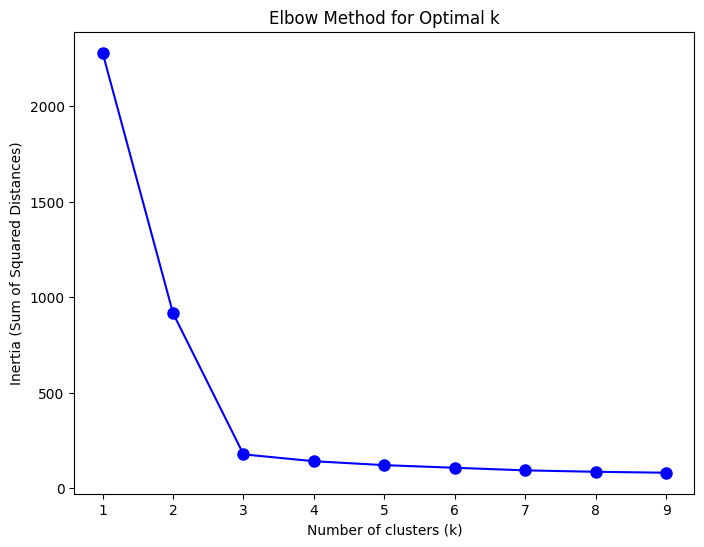

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Define the range of k values to try
k_values = range(1, 10)

# List to store the inertia values for each k
inertia_values = []

# Run KMeans with each k and store the inertia
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, 'bo-', markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3)
y_pred = kmeans.fit_predict(X)

# y_pred = kmeans.predict(X_test)
silhouette_avg = silhouette_score(X, y_pred)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.7462439114716364


In [ ]:
from collections import Counter

# Count the occurrences of each cluster label
cluster_counts = Counter(y_pred)

# Print the counts for each cluster
print(cluster_counts)

Counter({0: 400, 1: 139, 2: 130})


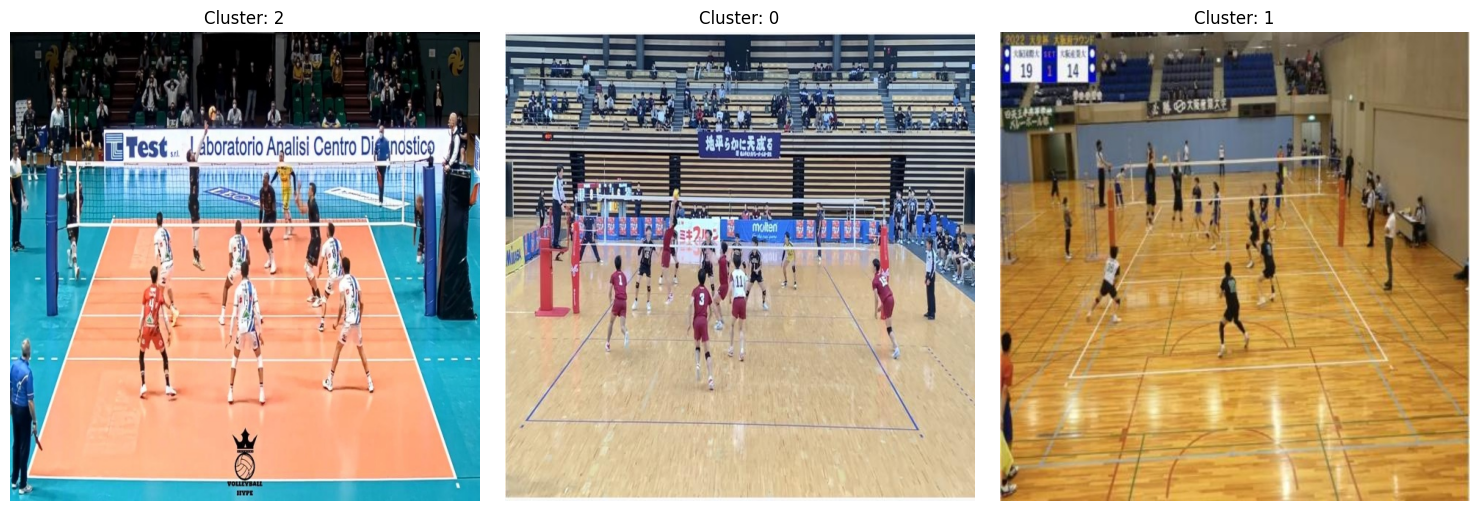

In [ ]:
filtered_image_paths = [image_paths for image_paths, m in zip(cleaned_hitting_images, mask) if m]
filtered_image_paths = filtered_image_paths[100:]
predicted_clusters = y_pred[100:]

clusters_to_images = {}
for image_path, cluster in zip(filtered_image_paths, predicted_clusters):
    if cluster not in clusters_to_images:
        clusters_to_images[cluster] = image_path
        if len(clusters_to_images) == 3:  # Stop once all 3 clusters have an image
            break

# Plot one image from each cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (cluster, image_path) in zip(axes, clusters_to_images.items()):
    image = Image.open(image_path)  # Open the image
    ax.imshow(image)
    ax.set_title(f"Cluster: {cluster}")
    ax.axis("off")

plt.tight_layout()
plt.show()

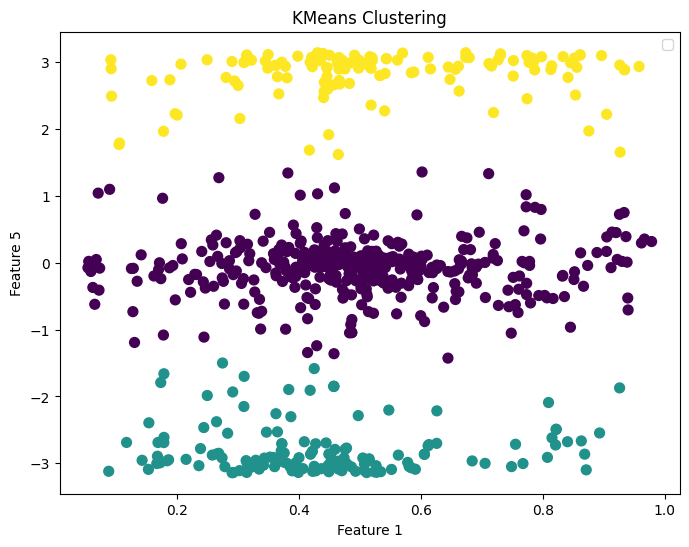

In [ ]:
# labels = kmeans.labels_
# centroids = kmeans.cluster_centers_

# # Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 4], c=y_pred, cmap='viridis', s=50)
# plt.scatter(centroids[:, 0], centroids[:, 2], s=200, c='red', marker='X', label='Centroids')
plt.title('KMeans Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 5')
plt.legend()
plt.show()

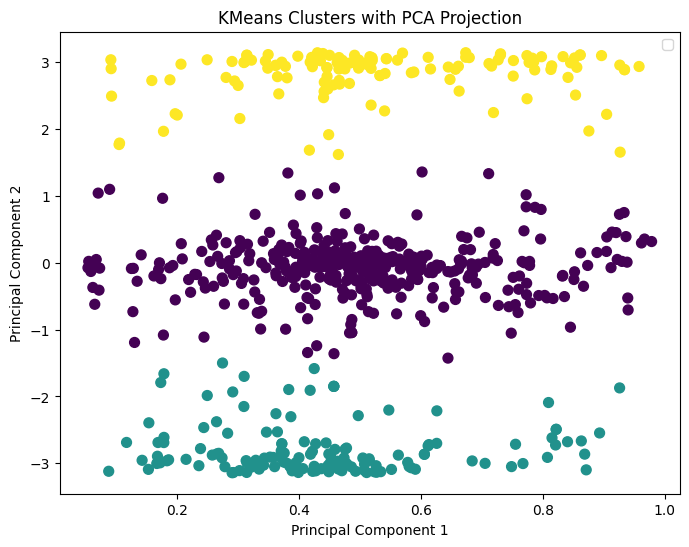

In [ ]:
from sklearn.decomposition import PCA

# Fit PCA
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X)  # Transform for the top 2 components

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 4], c=y_pred, cmap='viridis', s=50)
#plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x', label='Centroids')
plt.title("KMeans Clusters with PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

### Volo V8

The below code is in case I end up needing to use a pretrained Volo model.

In [ ]:
# with open('/content/Volleyball Actions.v5-original.yolov8/data.yaml', 'r') as f:
#     print(f.read())

In [ ]:
# need to make a .yaml file with the information about the cleaned images

# Set the path to your dataset
# dataset_path = '/content/content/cleaned_images'

# # Create the YAML content
# data_yaml = f"""
# train: {dataset_path}/train/images
# val: {dataset_path}/val/images
# test: {dataset_path}/test/images

# nc: 5
# names: ['block', 'defense', 'serve', 'set', 'spike']
# """

# # Write the content to the data.yaml file
# with open('/content/content/cleaned_images/data.yaml', 'w') as f:
#     f.write(data_yaml)

# print("data.yaml file created successfully!")

In [ ]:
# with open('/content/content/cleaned_images/data.yaml', 'r') as f:
#     print(f.read())

In [ ]:
from ultralytics import YOLO

# model = YOLO('yolov8n.pt')

# # Train the model
# model.train(
#     data='/content/content/cleaned_images/data.yaml',
#     epochs=50,
#     batch=16,
#     imgsz=640
# )

In [ ]:
# copied model after training
# !cp -r "./runs/detect/train/weights" "/content/gdrive/MyDrive/College/Mines/DSCI 503/yolov8_model"

# get model back
# Load the model from Google Drive
# model = YOLO('/content/gdrive/MyDrive/College/Mines/DSCI 503/yolov8_model/best.pt') # only 31 epochs were done

In [ ]:
import cv2
import numpy as np
import os

# # Directory of images
# image_dir = '/content/Volleyball Actions.v5-original.yolov8/train/images'
# image_files = train_images[:1000]

# # image_dir = '/content/content/cleaned_images/train/images'
# # image_files = cleaned_train_images[:1000]

# # extract information from the images using
# X = []
# for image_path in image_files:
#     #image_path = os.path.join(image_dir, image_file)
#     image = cv2.imread(image_path)

#     results = model(image)
#     for result in results:
#         detections = result.boxes

#         # Initialize feature vector for this image
#         image_features = []
#         for det in detections:
#             # Get class, confidence, and bounding box coordinates
#             class_id = int(det.cls.item())
#             confidence = float(det.conf.item())
#             x_center = float(det.xywh[0, 0].item())
#             y_center = float(det.xywh[0, 1].item())
#             width = float(det.xywh[0, 2].item())
#             height = float(det.xywh[0, 3].item())

#             # Optionally, only select relevant classes (e.g., players)
#             # if class_id not in [0, 1]:  # Example class filter
#             #     continue

#             # Combine all features into a single vector
#             object_features = [class_id, confidence, x_center, y_center, width, height]
#             image_features.extend(object_features)  # Aggregate all objects in the image

#         # Append image features to the feature matrix
#         X.append(image_features)

In [ ]:
# Preprocess extracted data for the below algorithms
# from sklearn.preprocessing import StandardScaler

# # labeled data w/ Yolov8
# # Define max number of detections per image
# max_detections = 1

# # Prepare a fixed-length feature array
# X_fixed = []

# for features in X:
#     # Limit to top 3 detections (or pad with zeros if fewer)
#     detections = np.array(features).reshape(-1, 6)  # Each detection has 6 features
#     detections = detections[:max_detections]        # Limit to top 3 detections
#     while len(detections) < max_detections:
#         detections = np.vstack([detections, np.zeros(6)])  # Pad with zeros
#     X_fixed.append(detections.flatten())  # Flatten to single row

# X_fixed = np.array(X_fixed)

# # Optionally, normalize features
# scaler = StandardScaler()
# X_fixed = scaler.fit_transform(X_fixed)
# print(X_fixed.shape)

In [ ]:
# labels_dir = '/content/content/cleaned_images/train/labels'
# label_paths = cleaned_train_labels[:1000]
# label_paths = train_labels[:1000]

# y = []
# for label_file in label_paths:
#     if label_file.endswith('.txt'):
#         # Path to the label file
#         # label_path = os.path.join(labels_dir, label_file)
#         label_path = label_file

#         # Read the label file and extract class IDs
#         with open(label_path, 'r') as file:
#             class_ids = [int(line.split()[0]) for line in file.readlines()]
#             y.append(class_ids[0] if class_ids else -1)  # Add all class IDs to the y list

# y = np.array(y)
# print(y.shape)

In [ ]:
# Split data into train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X_fixed, y[:1000], test_size=0.2, random_state=42)

### SVM Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize and train the SVM
# svm = SVC(kernel='linear')
# svm.fit(X_train, y_train)

# # Predict on the test set
# y_pred = svm.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred, average="weighted")
# recall = recall_score(y_test, y_pred, average="weighted")
# f1 = f1_score(y_test, y_pred, average="weighted")
# matrix = confusion_matrix(y_test, y_pred)
# print("Model Accuracy:", accuracy)
# print("Model Precision:", precision)
# print("Model Recall:", recall)
# print("Model F1-Score:", f1)
# print("Confusion Matrix:\n", matrix)

### KMeans

We don't have actually labeled image data, so it makes sense to cluster the extracted information together and use silhouette score to see how strong the clustering is.

In [ ]:
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score

# # Define the range of k values to try
# k_values = range(1, 18)

# # List to store the inertia values for each k
# inertia_values = []

# # Run KMeans with each k and store the inertia
# for k in k_values:
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     kmeans.fit(X_train)
#     inertia_values.append(kmeans.inertia_)

# # Plot the results
# plt.figure(figsize=(8, 6))
# plt.plot(k_values, inertia_values, 'bo-', markersize=8)
# plt.xlabel('Number of clusters (k)')
# plt.ylabel('Inertia (Sum of Squared Distances)')
# plt.title('Elbow Method for Optimal k')
# plt.show()

In [ ]:
# kmeans = KMeans(n_clusters=4)
# kmeans.fit(X_train)

# y_pred = kmeans.predict(X_test)
# silhouette_avg = silhouette_score(X_test, y_pred)
# print("Silhouette Score:", silhouette_avg)

In [ ]:
# labels = kmeans.labels_
# centroids = kmeans.cluster_centers_

# # Plotting
# plt.figure(figsize=(8, 6))
# plt.scatter(X_train[:, 7], X_train[:, 8], c=labels, cmap='viridis', marker='o', edgecolor='k', alpha=0.6)
# plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='Centroids')
# plt.title('KMeans Clustering')
# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')
# plt.legend()
# plt.show()